In [1]:
import pandas as pd

df = pd.read_csv("training.1600000.processed.noemoticon.csv",
                 encoding="latin-1",
                 header=None,
                 names=["target", "ids", "date", "flag", "user", "text"])

print(df.shape)
print(df.head(3))

(1600000, 6)
   target         ids                          date      flag  \
0       0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY   
1       0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY   
2       0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY   

              user                                               text  
0  _TheSpecialOne_  @switchfoot http://twitpic.com/2y1zl - Awww, t...  
1    scotthamilton  is upset that he can't update his Facebook by ...  
2         mattycus  @Kenichan I dived many times for the ball. Man...  


In [2]:
india_keywords = [
    "india", "indian", "delhi", "mumbai", "bangalore", "modi",
    "bollywood", "rupee", "cricket", "pollution", "farmer",
    "election", "bjp", "congress", "kashmir", "unemployment",
    "inflation", "poverty", "chennai", "kolkata", "hyderabad"
]

pattern = "|".join(india_keywords)

india_df = df[df["text"].str.contains(pattern, case=False, na=False)].copy()

print(f"India-related tweets found: {len(india_df)}")
india_df[["target", "text"]].head(5)

India-related tweets found: 4491


,target,text
138,0,"...and, India missed out its 100th Test victor..."
564,0,http://twitpic.com/2y3cf - Filled with curry ...
803,0,I accessed oneindia.mobi from a Google phone (...
2045,0,What is common between Chidambaram and George ...
3553,0,My phone is BROKE. Too bad I could have been ...


In [3]:
import re
import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords

# 0 = Negative, 4 = Positive (no neutral in this dataset)
india_df["sentiment"] = india_df["target"].map({0: "Negative", 2: "Neutral", 4: "Positive"})

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)        # remove URLs
    text = re.sub(r"@\w+", "", text)           # remove @mentions
    text = re.sub(r"#(\w+)", r"\1", text)      # keep hashtag word
    text = re.sub(r"[^a-z\s]", "", text)       # remove punctuation
    words = [w for w in text.split() if w not in stop_words and len(w) > 2]
    return " ".join(words)

india_df["clean_text"] = india_df["text"].apply(clean_text)

print(india_df[["text", "clean_text", "sentiment"]].head(3))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ganva\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                                  text  \
138  ...and, India missed out its 100th Test victor...   
564  http://twitpic.com/2y3cf - Filled with curry  ...   
803  I accessed oneindia.mobi from a Google phone (...   

                                            clean_text sentiment  
138  india missed test victory consecutive win with...  Negative  
564                    filled curry true indian coming  Negative  
803  accessed oneindiamobi google phone android doe...  Negative  


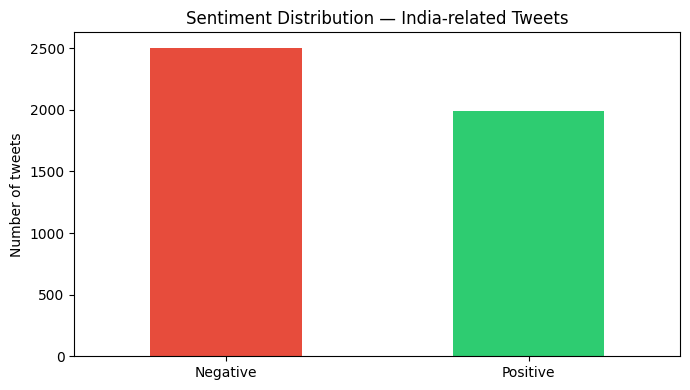

In [4]:
import matplotlib.pyplot as plt

counts = india_df["sentiment"].value_counts()
colors = [{"Positive": "#2ecc71", "Neutral": "#95a5a6", "Negative": "#e74c3c"}.get(x, "gray") for x in counts.index]

plt.figure(figsize=(7, 4))
counts.plot(kind="bar", color=colors, edgecolor="none")
plt.title("Sentiment Distribution — India-related Tweets")
plt.xlabel("")
plt.ylabel("Number of tweets")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("sentiment_distribution.png", dpi=150)
plt.show()

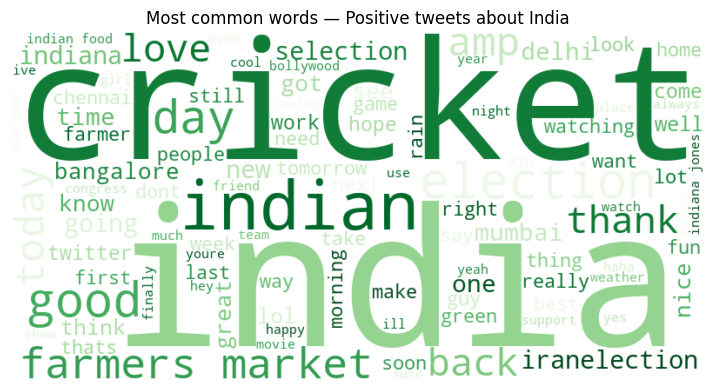

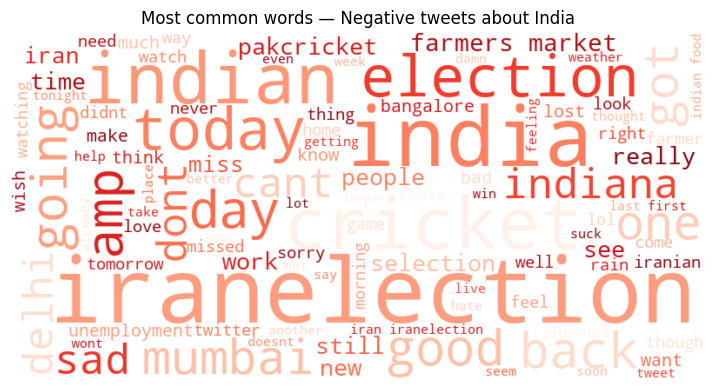

In [5]:
from wordcloud import WordCloud

for sentiment in ["Positive", "Negative"]:
    text = " ".join(india_df[india_df["sentiment"] == sentiment]["clean_text"])
    
    colormap = "Greens" if sentiment == "Positive" else "Reds"
    
    wc = WordCloud(width=800, height=400,
                   background_color="white",
                   colormap=colormap,
                   max_words=100).generate(text)
    
    plt.figure(figsize=(10, 4))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Most common words — {sentiment} tweets about India")
    plt.tight_layout()
    plt.savefig(f"wordcloud_{sentiment.lower()}.png", dpi=150)
    plt.show()

In [6]:
# Convert date column to datetime
india_df["date"] = pd.to_datetime(india_df["date"], format="%a %b %d %H:%M:%S PDT %Y")

# Extract just the date (no time)
india_df["day"] = india_df["date"].dt.date

# Count sentiments per day
time_df = india_df.groupby(["day", "sentiment"]).size().unstack(fill_value=0)

print(time_df.head())

sentiment   Negative  Positive
day                           
2009-04-06         3         8
2009-04-07        21        26
2009-04-17         2         3
2009-04-18        30        38
2009-04-19        52        44


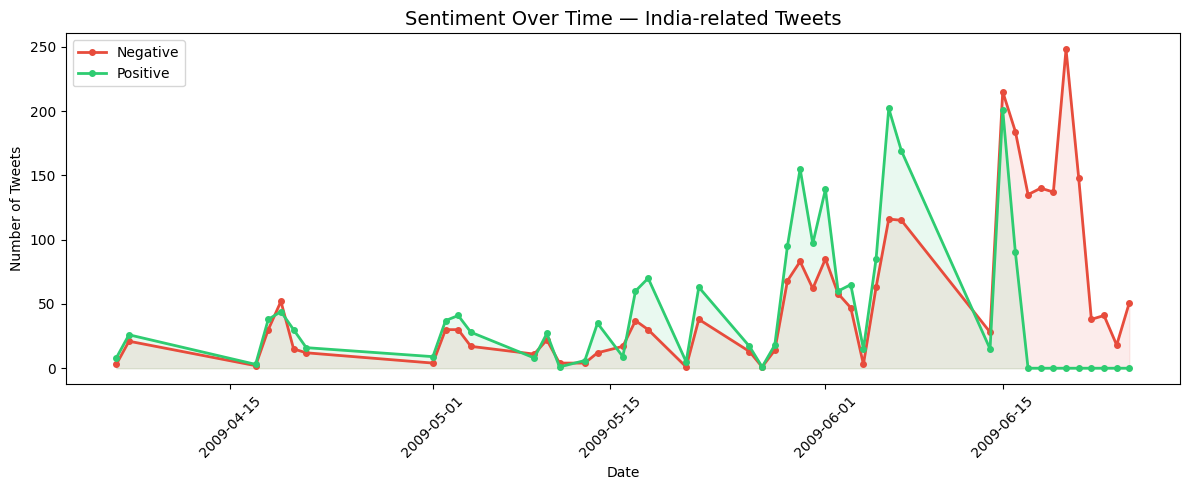

In [7]:
plt.figure(figsize=(12, 5))

plt.plot(time_df.index, time_df["Negative"], 
         color="#e74c3c", linewidth=2, marker="o", markersize=4, label="Negative")

plt.plot(time_df.index, time_df["Positive"], 
         color="#2ecc71", linewidth=2, marker="o", markersize=4, label="Positive")

plt.fill_between(time_df.index, time_df["Negative"], alpha=0.1, color="#e74c3c")
plt.fill_between(time_df.index, time_df["Positive"], alpha=0.1, color="#2ecc71")

plt.title("Sentiment Over Time — India-related Tweets", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Number of Tweets")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("sentiment_over_time.png", dpi=150)
plt.show()